This colab creates 3 different datasets:

**balanced_df** = using every single song per decade, downsampled randomly until 20% hit rate

**balanced_df_2000** = downsampled randomly but until there's only 2000 songs and also 20% hit rate

**balanced_1700_unPOP_df** = downsampled by only keeping the non-hits that have a 0 of popularity spotify score but until there's only 1700 songs and also 20% hit rate. 1700 was chosen because there weren't enough songs in the 60s.

Utlitmately, we chose to use balanced_df_2000 for our expirements

In [ ]:
!pip install opendatasets -q

import opendatasets as od
od.download('https://www.kaggle.com/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres?select=songs.csv')
od.download('https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nhern026
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres


100%|██████████| 235M/235M [00:01<00:00, 146MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nhern026
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs


100%|██████████| 3.05M/3.05M [00:00<00:00, 147MB/s]

In [ ]:
import pandas as pd
import re

songs_df   = pd.read_csv('/content/550k-spotify-songs-audio-lyrics-and-genres/songs.csv')
charts_df  = pd.read_csv('/content/billboard-the-hot-100-songs/charts.csv')

# showing all features in the dataset
print('songs_df columns:', songs_df.columns.tolist())
print('songs_df shape:  ', songs_df.shape)

songs_df columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']
songs_df shape:   (550622, 24)


In [ ]:
# printing # of songs per decade
songs_df['decade'] = (songs_df['year'] // 10 * 10).astype(str) + 's'
print(songs_df.groupby('decade').size().to_string())

decade
1900s        30
1910s         3
1920s       156
1930s       288
1940s       437
1950s      4119
1960s     11344
1970s     17570
1980s     20729
1990s     42913
2000s    162161
2010s    225362
2020s     65510


In [ ]:
import ast

def normalize_text(text):
    if pd.isna(text): return ''
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# keeping first artist
def clean_artist_name(artist):
    for sep in [' featuring ', ' feat. ', ' feat ', ' ft. ', ' ft ', ' x ', ' & ', ' with ']:
        artist = artist.lower().split(sep)[0]
    return artist.strip()

# keeping only the first artist
def get_primary_artist(artists_str):
    try:
        artists_list = ast.literal_eval(artists_str)
        return normalize_text(artists_list[0])
    except:
        return clean_artist_name(normalize_text(str(artists_str)))

#setting up the normalized song titles and artist names for matching in the next section
songs_df['song_normalized']   = songs_df['name'].apply(normalize_text)
songs_df['artist_normalized'] = songs_df['artists'].apply(get_primary_artist)

charts_df['song_normalized']   = charts_df['song'].apply(normalize_text)
charts_df['artist_normalized'] = charts_df['artist'].apply(lambda x: clean_artist_name(normalize_text(x)))

In [ ]:
# creating the is_hit label feature to songs dataframe
# a song is a hit if it ever reached top 10, matched on song + artist name
top10 = charts_df[charts_df['rank'] <= 10][['song_normalized', 'artist_normalized']].drop_duplicates()
top10['is_hit'] = 1

songs_df = songs_df.merge(top10, on=['song_normalized', 'artist_normalized'], how='left')
songs_df['is_hit'] = songs_df['is_hit'].fillna(0).astype(int)

print(f"Total songs:  {len(songs_df):,}")
print(f"Hits (top10): {songs_df['is_hit'].sum():,}")
print(f"Overall hit rate: {songs_df['is_hit'].mean():.1%}")

Total songs:  550,622
Hits (top10): 7,292
Overall hit rate: 1.3%


In [ ]:
# checking how many hits we have per decade in a percentage (hint: not a lot!)
decade_stats = songs_df.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

         total  hits hit_rate
decade                       
1960s    11344   437     3.9%
1970s    17570   604     3.4%
1980s    20729   796     3.8%
1990s    42913   850     2.0%
2000s   162161  1821     1.1%
2010s   225362  2128     0.9%
2020s    65510   620     0.9%


In [ ]:
# @title Only using non-hits that are popularity 0 metric

print(songs_df.columns.tolist())
songs_df_unPop = songs_df[~((songs_df['popularity'] > 0) & (songs_df['is_hit'] == 0))]

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
# checking how many hits we have per decade in a percentage after taking out non-zero non_hit songs
decade_stats = songs_df_unPop.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

        total  hits hit_rate
decade                      
1960s    1798   437    24.3%
1970s    3496   604    17.3%
1980s    4212   796    18.9%
1990s   10536   850     8.1%
2000s   43777  1821     4.2%
2010s   70817  2128     3.0%
2020s   18636   620     3.3%


In [ ]:
# @title Downsample 1700 - downsample only with 0 popularity songs for non-hits
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df_unPop.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 340
    target_non_hits = 340 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_1700_unPOP_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_1700_unPOP_df):,} songs")

1960s: 340 hits, 1360 non-hits, hit rate: 20.0%
1970s: 340 hits, 1360 non-hits, hit rate: 20.0%
1980s: 340 hits, 1360 non-hits, hit rate: 20.0%
1990s: 340 hits, 1360 non-hits, hit rate: 20.0%
2000s: 340 hits, 1360 non-hits, hit rate: 20.0%
2010s: 340 hits, 1360 non-hits, hit rate: 20.0%
2020s: 340 hits, 1360 non-hits, hit rate: 20.0%

Total: 11,900 songs


In [ ]:
# @title Downsample 2000 - random Downsample
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 400
    target_non_hits = 400 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_2000_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_2000_df):,} songs")

1960s: 400 hits, 1600 non-hits, hit rate: 20.0%
1970s: 400 hits, 1600 non-hits, hit rate: 20.0%
1980s: 400 hits, 1600 non-hits, hit rate: 20.0%
1990s: 400 hits, 1600 non-hits, hit rate: 20.0%
2000s: 400 hits, 1600 non-hits, hit rate: 20.0%
2010s: 400 hits, 1600 non-hits, hit rate: 20.0%
2020s: 400 hits, 1600 non-hits, hit rate: 20.0%

Total: 14,000 songs


In [ ]:
# @title Downsample Full
# downsampling to 20% hit rate
balanced_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_non_hits = min(len(hits) * 4, len(non_hits))
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced = pd.concat([hits, non_hits_sampled])
    balanced_decades.append(balanced)
    print(f"{decade}: {len(hits)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits)/len(balanced):.1%}")

balanced_df = pd.concat(balanced_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_df):,} songs")

1960s: 437 hits, 1748 non-hits, hit rate: 20.0%
1970s: 604 hits, 2416 non-hits, hit rate: 20.0%
1980s: 796 hits, 3184 non-hits, hit rate: 20.0%
1990s: 850 hits, 3400 non-hits, hit rate: 20.0%
2000s: 1821 hits, 7284 non-hits, hit rate: 20.0%
2010s: 2128 hits, 8512 non-hits, hit rate: 20.0%
2020s: 620 hits, 2480 non-hits, hit rate: 20.0%

Total: 36,280 songs


In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
balanced_2000_df = balanced_2000_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]
balanced_df = balanced_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit']]
balanced_1700_unPOP_df = balanced_1700_unPOP_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit']]

In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']


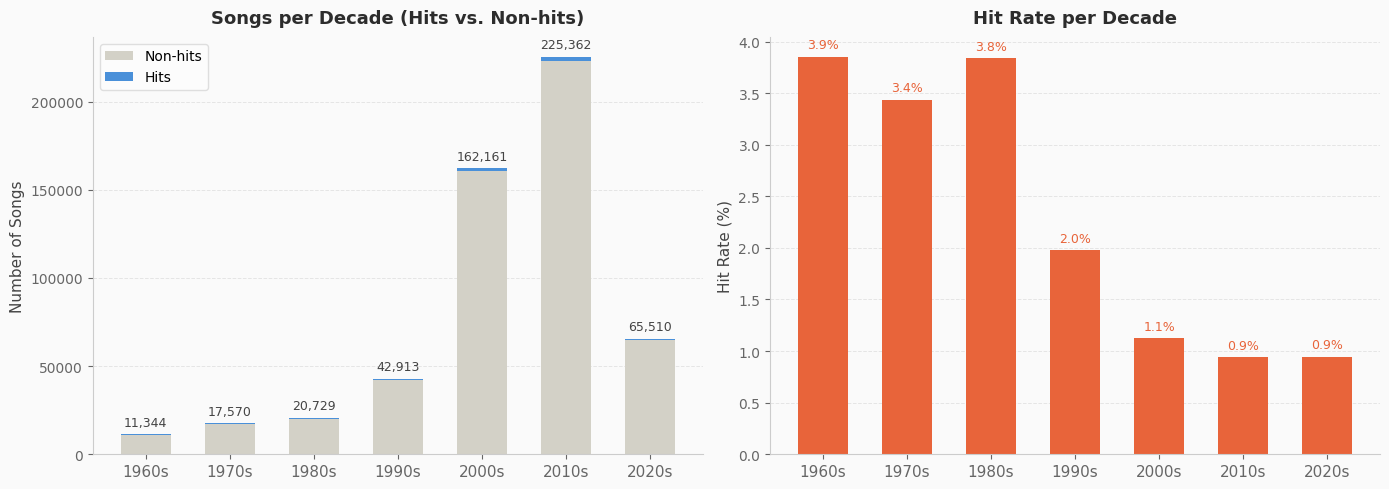

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decade_counts = songs_df[songs_df['decade'] >= '1960s'].groupby('decade').size()
hit_counts    = songs_df[songs_df['decade'] >= '1960s'].groupby('decade')['is_hit'].sum()
non_hit_counts = decade_counts - hit_counts

decades = decade_counts.index.tolist()
x = np.arange(len(decades))

colors = {'Hits': '#4A90D9', 'Non-hits': '#D3D1C7'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')

# ── LEFT: stacked bar of hits vs non-hits ──────────────────────────────────
ax = axes[0]
ax.set_facecolor('#FAFAFA')

bars_non = ax.bar(x, non_hit_counts, color=colors['Non-hits'], label='Non-hits', width=0.6)
bars_hit  = ax.bar(x, hit_counts, bottom=non_hit_counts, color=colors['Hits'], label='Hits', width=0.6)

for xi, total in zip(x, decade_counts):
    ax.annotate(f'{total:,}', (xi, total), textcoords='offset points',
                xytext=(0, 6), ha='center', fontsize=9, color='#444444')

ax.set_xticks(x)
ax.set_xticklabels(decades, fontsize=11)
ax.set_ylabel('Number of Songs', fontsize=11, color='#444444')
ax.set_title('Songs per Decade (Hits vs. Non-hits)', fontsize=13,
             fontweight='bold', pad=10, color='#2C2C2C')
ax.tick_params(colors='#666666')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

# ── RIGHT: hit rate % per decade ───────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')

hit_rates = (hit_counts / decade_counts * 100).values

bars = ax2.bar(x, hit_rates, color='#E8643A', width=0.6)

for xi, v in zip(x, hit_rates):
    ax2.annotate(f'{v:.1f}%', (xi, v), textcoords='offset points',
                 xytext=(0, 6), ha='center', fontsize=9, color='#E8643A')

ax2.set_xticks(x)
ax2.set_xticklabels(decades, fontsize=11)
ax2.set_ylabel('Hit Rate (%)', fontsize=11, color='#444444')
ax2.set_title('Hit Rate per Decade', fontsize=13,
              fontweight='bold', pad=10, color='#2C2C2C')
ax2.tick_params(colors='#666666')
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#CCCCCC')
ax2.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('songs_per_decade.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

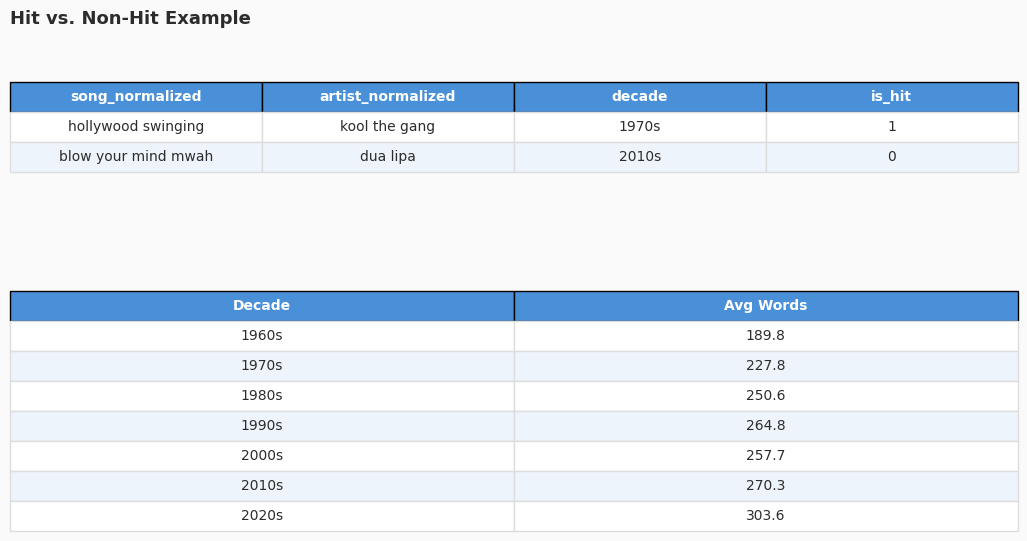

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Pull examples ─────────────────────────────────────────────────────────
hit = balanced_2000_df[(balanced_2000_df['is_hit'] == 1) & (balanced_2000_df['decade'] == '1970s')].iloc[1]
non_hit = balanced_2000_df[(balanced_2000_df['is_hit'] == 0) & (balanced_2000_df['decade'] == '2010s')].iloc[2]

# ── Lyric stats ───────────────────────────────────────────────────────────
lyrics_stats = balanced_2000_df.groupby('decade')['lyrics'].apply(
    lambda x: x.dropna().str.split().str.len().mean()
).round(1).reset_index()
lyrics_stats.columns = ['Decade', 'Avg Words']

# ── Layout ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 6), facecolor='#FAFAFA')
gs = gridspec.GridSpec(2, 1, hspace=0.6)

HEADER_COLOR = '#4A90D9'
ROW_COLORS   = ['#FFFFFF', '#EEF4FB']
TEXT_COLOR   = '#2C2C2C'

# ── Table 1: Hit vs Non-hit ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.axis('off')
ax1.set_title('Hit vs. Non-Hit Example', fontsize=13, fontweight='bold',
               color=TEXT_COLOR, pad=10, loc='left')

cols = ['song_normalized', 'artist_normalized', 'decade', 'is_hit']
rows = [
    [hit['song_normalized'],     hit['artist_normalized'],     hit['decade'],     '1'],
    [non_hit['song_normalized'], non_hit['artist_normalized'], non_hit['decade'], '0'],
]

t1 = ax1.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
t1.auto_set_font_size(False)
t1.set_fontsize(10)
t1.scale(1, 1.8)

for j in range(len(cols)):
    cell = t1[0, j]
    cell.set_facecolor(HEADER_COLOR)
    cell.set_text_props(color='white', fontweight='bold')

for i in range(len(rows)):
    for j in range(len(cols)):
        cell = t1[i+1, j]
        cell.set_facecolor(ROW_COLORS[i % 2])
        cell.set_text_props(color=TEXT_COLOR)
        cell.set_edgecolor('#DDDDDD')

# ── Table 2: Avg lyric length ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')
ax2.set_title('', fontsize=13, fontweight='bold',
               color=TEXT_COLOR, pad=10, loc='left')

cols2 = lyrics_stats.columns.tolist()
rows2 = lyrics_stats.values.tolist()

t2 = ax2.table(cellText=rows2, colLabels=cols2, loc='center', cellLoc='center')
t2.auto_set_font_size(False)
t2.set_fontsize(10)
t2.scale(1, 1.8)

for j in range(len(cols2)):
    cell = t2[0, j]
    cell.set_facecolor(HEADER_COLOR)
    cell.set_text_props(color='white', fontweight='bold')

for i in range(len(rows2)):
    for j in range(len(cols2)):
        cell = t2[i+1, j]
        cell.set_facecolor(ROW_COLORS[i % 2])
        cell.set_text_props(color=TEXT_COLOR)
        cell.set_edgecolor('#DDDDDD')

plt.savefig('slide_tables.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

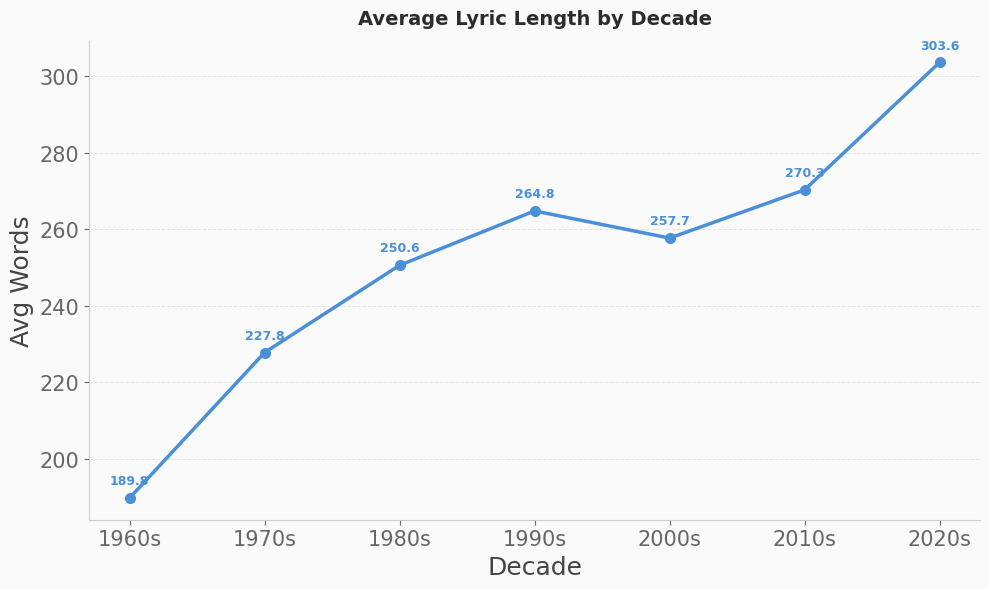

In [ ]:
# ── Lyric stats ───────────────────────────────────────────────────────────
lyrics_stats = balanced_2000_df.groupby('decade')['lyrics'].apply(
    lambda x: x.dropna().str.split().str.len().mean()
).round(1).reset_index()
lyrics_stats.columns = ['Decade', 'Avg Words']

# ── Line graph ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.plot(lyrics_stats['Decade'], lyrics_stats['Avg Words'],
        color='#4A90D9', linewidth=2.5, marker='o', markersize=7, zorder=3)

for _, row in lyrics_stats.iterrows():
    ax.annotate(f"{row['Avg Words']}", (row['Decade'], row['Avg Words']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#4A90D9', fontweight='bold')

ax.set_title('Average Lyric Length by Decade', fontsize=14,
             fontweight='bold', color='#2C2C2C', pad=12)
ax.set_xlabel('Decade', fontsize=18, color='#444444')
ax.set_ylabel('Avg Words', fontsize=18, color='#444444')
ax.tick_params(colors='#666666', labelsize=15)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('lyric_length_by_decade.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

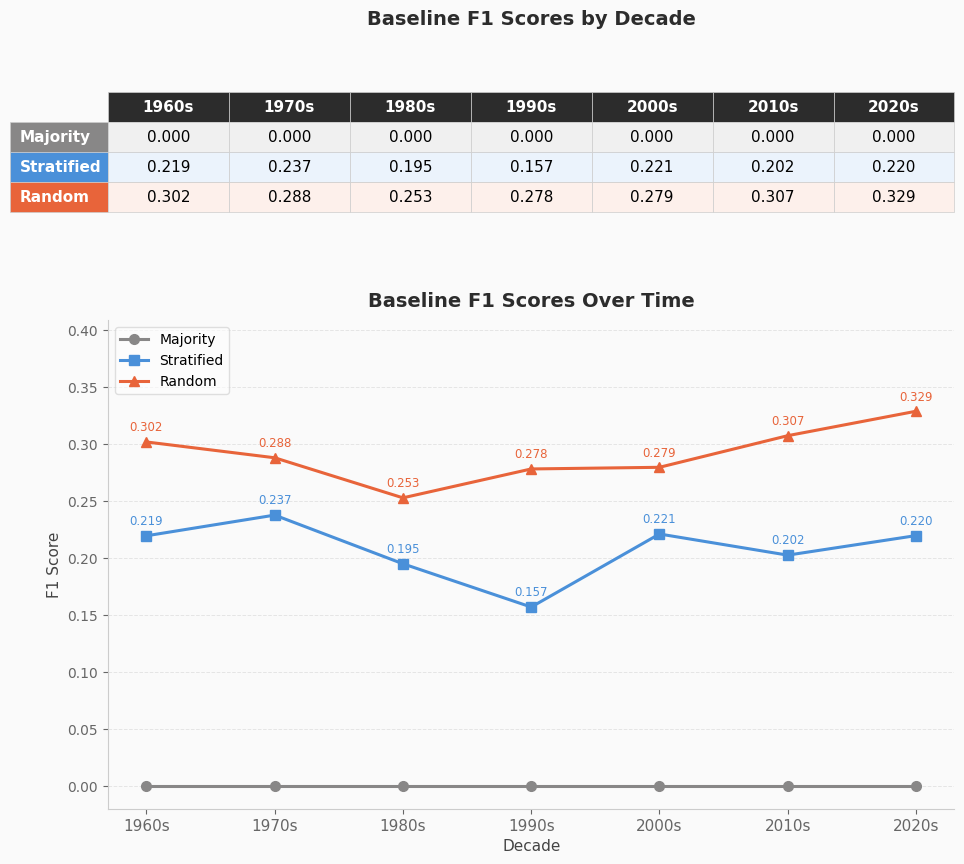

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# ── Run baselines and collect results dynamically ─────────────────────────
results = {strategy: {} for strategy in ['Majority', 'Stratified', 'Random']}
strategy_map = {'Majority': 'most_frequent', 'Stratified': 'stratified', 'Random': 'uniform'}

for decade, group in balanced_2000_df.groupby('decade'):
    X = group['lyrics']
    y = group['is_hit']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )
    for name, strategy in strategy_map.items():
        clf = DummyClassifier(strategy=strategy)
        clf.fit(X_train.to_frame(), y_train)
        preds = clf.predict(X_test.to_frame())
        results[name][decade] = f1_score(y_test, preds, zero_division=0)

decades = sorted(results['Majority'].keys())
data = {name: [results[name][d] for d in decades] for name in results}

# ── Plotting ──────────────────────────────────────────────────────────────
colors  = {'Majority': '#888787', 'Stratified': '#4A90D9', 'Random': '#E8643A'}
markers = {'Majority': 'o',       'Stratified': 's',       'Random': '^'}

fig, (ax_table, ax_chart) = plt.subplots(2, 1, figsize=(10, 9),
                                          gridspec_kw={'height_ratios': [1, 2.2]})
fig.patch.set_facecolor('#FAFAFA')

# ── TABLE ──────────────────────────────────────────────────────────────────
ax_table.axis('off')
ax_table.set_facecolor('#FAFAFA')

row_labels = list(data.keys())
cell_text  = [[f'{v:.3f}' for v in data[bl]] for bl in row_labels]

table = ax_table.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=decades,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 1.6)

row_colors = ['#F0F0F0', '#EBF3FC', '#FDF0EB']

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor('#2C2C2C')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_facecolor(colors[row_labels[row - 1]])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[row - 1])

ax_table.set_title('Baseline F1 Scores by Decade', fontsize=14,
                   fontweight='bold', pad=12, color='#2C2C2C')

# ── CHART ──────────────────────────────────────────────────────────────────
ax_chart.set_facecolor('#FAFAFA')
x = np.arange(len(decades))

for bl, vals in data.items():
    ax_chart.plot(x, vals, color=colors[bl], marker=markers[bl],
                  linewidth=2.2, markersize=7, label=bl)
    for xi, v in zip(x, vals):
        if v > 0:
            ax_chart.annotate(f'{v:.3f}', (xi, v),
                              textcoords='offset points', xytext=(0, 8),
                              ha='center', fontsize=8.5, color=colors[bl])

ax_chart.set_xticks(x)
ax_chart.set_xticklabels(decades, fontsize=11)
ax_chart.set_ylim(-0.02, max(max(v) for v in data.values()) + 0.08)
ax_chart.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax_chart.set_xlabel('Decade', fontsize=11, color='#444444')
ax_chart.set_title('Baseline F1 Scores Over Time', fontsize=14,
                   fontweight='bold', pad=10, color='#2C2C2C')
ax_chart.tick_params(colors='#666666')
ax_chart.spines[['top', 'right']].set_visible(False)
ax_chart.spines[['left', 'bottom']].set_color('#CCCCCC')
ax_chart.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax_chart.set_axisbelow(True)
ax_chart.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

plt.tight_layout(pad=2.0)
plt.savefig('baseline_f1.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [ ]:
!pip install wordcloud -q

In [ ]:
!pip install better-profanity -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.2 MB/s eta 0:00:00


Cleaning lyrics...
Building corpora...
Computing term frequencies...
Computing distinctiveness scores...
Generating word clouds...


/tmp/ipykernel_17015/2580993477.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


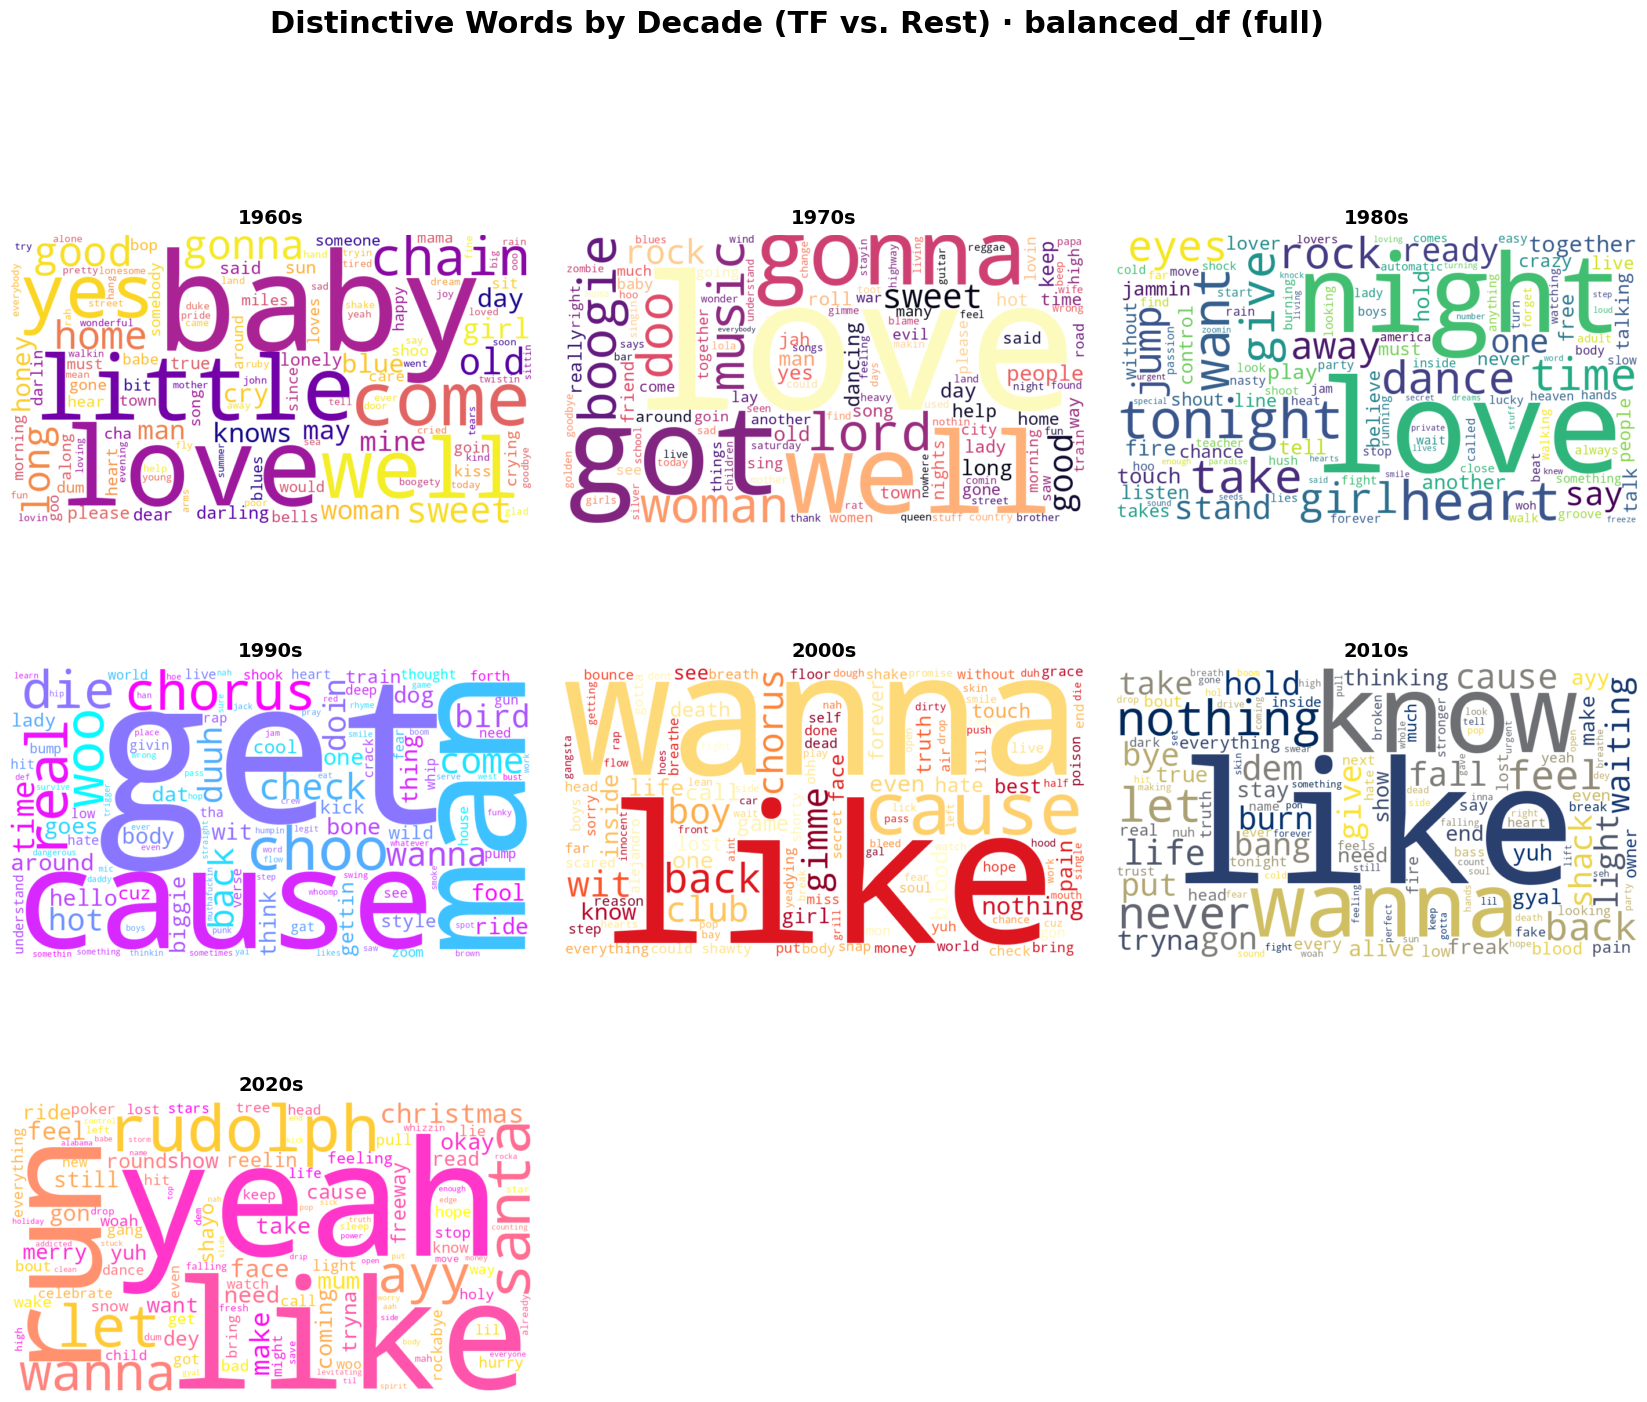

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from better_profanity import profanity
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nltk
import re
import numpy as np

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

profanity.load_censor_words()

STOPWORDS = set(stopwords.words('english')) | {str(w) for w in profanity.CENSOR_WORDSET} | {
    "oh", "ah", "na", "la", "da", "ooh", "hey", "ha",
    "t", "s", "m", "re", "ll", "ve", "d",
}

def clean_lyrics(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(words)

# ── Rejoin decade ──────────────────────────────────────────────────────────
decade_lookup = songs_df[["id", "decade"]].drop_duplicates("id")
df_wc = balanced_df.merge(decade_lookup, on="id", how="left")

print("Cleaning lyrics...")
df_wc["lyrics_clean"] = df_wc["lyrics"].apply(clean_lyrics)

# ── One corpus per decade ──────────────────────────────────────────────────
print("Building corpora...")
groups = df_wc.groupby("decade")["lyrics_clean"].apply(" ".join).reset_index()
groups.columns = ["decade", "corpus"]
decades_sorted = sorted(groups["decade"].unique())

# ── Term frequency (normalized) per decade ────────────────────────────────
print("Computing term frequencies...")
vectorizer = TfidfVectorizer(max_features=5000, use_idf=False, norm="l1")
tf_matrix = vectorizer.fit_transform(groups["corpus"]).toarray()
vocab = vectorizer.get_feature_names_out()
n_decades = len(decades_sorted)

# ── Distinctiveness = TF(this decade) - mean TF(all other decades) ────────
print("Computing distinctiveness scores...")
tfidf_dicts = {}
for i, decade in enumerate(decades_sorted):
    this_tf  = tf_matrix[i]
    other_tf = np.mean(tf_matrix[np.arange(n_decades) != i], axis=0)
    diff     = this_tf - other_tf

    # Keep only words more frequent in this decade than others
    word_scores = {
        vocab[j]: diff[j]
        for j in diff.argsort()[::-1][:200]
        if diff[j] > 0
    }
    tfidf_dicts[decade] = word_scores

# ── Plot ───────────────────────────────────────────────────────────────────
print("Generating word clouds...")
n = len(decades_sorted)
ncols = 3
nrows = -(-n // ncols)

PALETTES = ["plasma", "magma", "viridis", "cool", "YlOrRd", "cividis", "spring", "autumn"]

fig = plt.figure(figsize=(ncols * 7, nrows * 5.2), facecolor="white")
fig.suptitle("Distinctive Words by Decade (TF vs. Rest) · balanced_df (full)",
             fontsize=22, fontweight="bold", color="black", y=1.01)

gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.3, wspace=0.06)

for idx, decade in enumerate(decades_sorted):
    word_scores = tfidf_dicts.get(decade, {})
    ax = fig.add_subplot(gs[idx // ncols, idx % ncols])

    if not word_scores:
        ax.axis("off")
        continue

    wc = WordCloud(
        width=900, height=500,
        background_color="white",
        colormap=PALETTES[idx % len(PALETTES)],
        max_words=120,
        prefer_horizontal=0.85,
        min_font_size=9,
    ).generate_from_frequencies(word_scores)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(str(decade), color="black", fontsize=14, fontweight="bold", pad=8)

for i in range(n, nrows * ncols):
    fig.add_subplot(gs[i // ncols, i % ncols]).set_visible(False)

plt.tight_layout()
plt.savefig("wordclouds_distinctive_by_decade.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Cleaning lyrics...
Building corpora...
Computing distinctiveness scores...
Generating word clouds...


/tmp/ipykernel_17015/2652834449.py:91: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17015/2652834449.py:92: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig("wordclouds_1970s_hit_vs_nonhit.png", dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


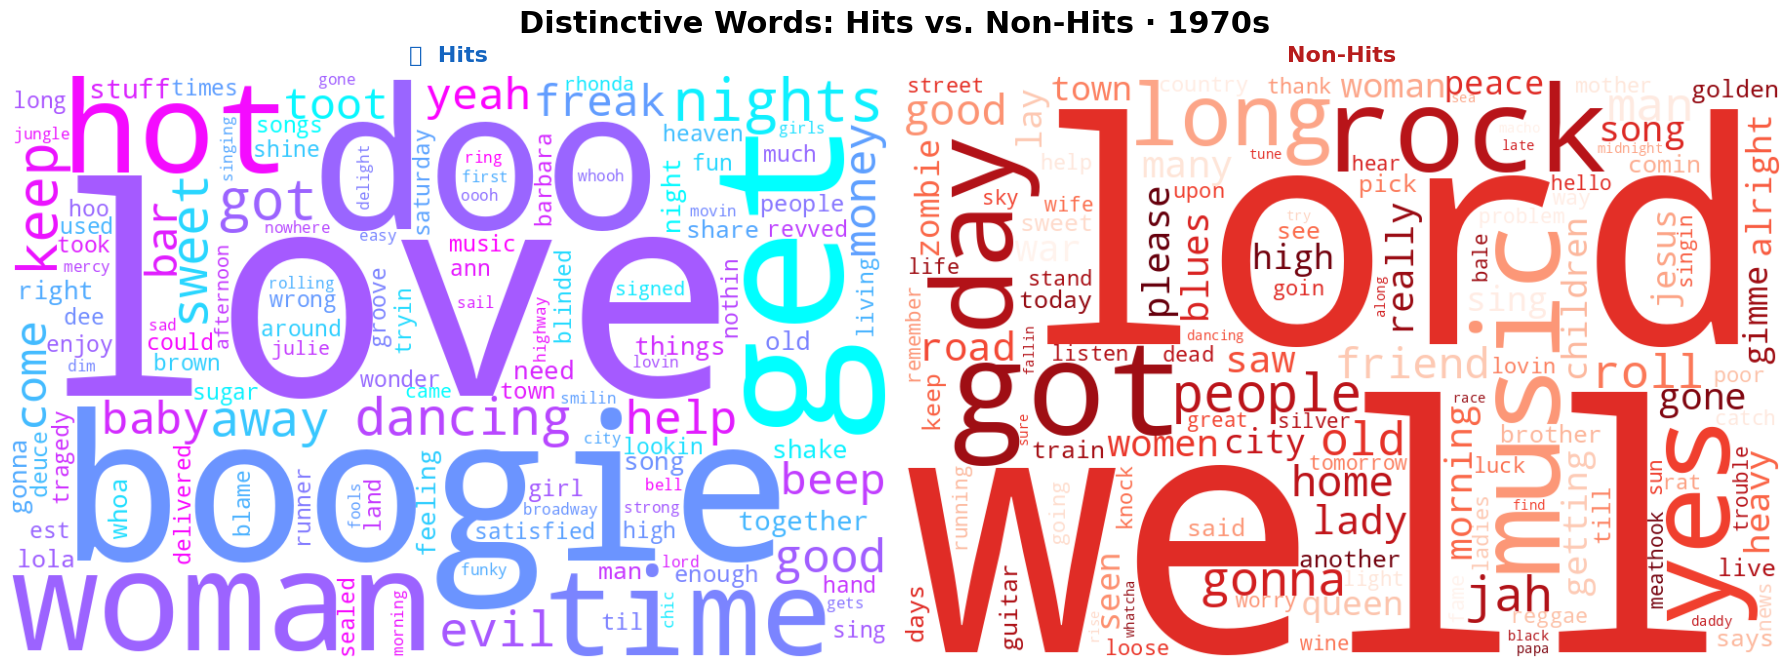

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from better_profanity import profanity
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nltk
import re
import numpy as np

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

profanity.load_censor_words()

STOPWORDS = set(stopwords.words('english')) | {str(w) for w in profanity.CENSOR_WORDSET} | {
    "oh", "ah", "na", "la", "da", "ooh", "hey", "ha",
    "t", "s", "m", "re", "ll", "ve", "d",
}

def clean_lyrics(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(words)

# ── Rejoin decade ──────────────────────────────────────────────────────────
decade_lookup = songs_df[["id", "decade"]].drop_duplicates("id")
df_wc = balanced_df.merge(decade_lookup, on="id", how="left")

print("Cleaning lyrics...")
df_wc["lyrics_clean"] = df_wc["lyrics"].apply(clean_lyrics)

# ── One corpus per (decade, is_hit) — all decades for contrast ────────────
print("Building corpora...")
groups = (
    df_wc.groupby(["decade", "is_hit"])["lyrics_clean"]
    .apply(" ".join)
    .reset_index()
)
groups.columns = ["decade", "is_hit", "corpus"]

# ── Fit on ALL groups so contrast is meaningful ───────────────────────────
print("Computing distinctiveness scores...")
vectorizer = TfidfVectorizer(max_features=5000, use_idf=False, norm="l1")
tf_matrix = vectorizer.fit_transform(groups["corpus"]).toarray()
vocab = vectorizer.get_feature_names_out()
n_groups = len(groups)

tfidf_dicts = {}
for i, row in groups.iterrows():
    this_tf  = tf_matrix[i]
    other_tf = np.mean(tf_matrix[np.arange(n_groups) != i], axis=0)
    diff     = this_tf - other_tf
    word_scores = {
        vocab[j]: diff[j]
        for j in diff.argsort()[::-1][:200]
        if diff[j] > 0
    }
    tfidf_dicts[(row["decade"], row["is_hit"])] = word_scores

# ── Plot 1970s only ───────────────────────────────────────────────────────
print("Generating word clouds...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor="white")
fig.suptitle("Distinctive Words: Hits vs. Non-Hits · 1970s",
             fontsize=22, fontweight="bold", color="black")

for ax, (is_hit, colormap, label) in zip(axes, [
    (1, "cool", "🎵  Hits"),
    (0, "Reds", "Non-Hits"),
]):
    word_scores = tfidf_dicts.get(("1970s", is_hit), {})
    if not word_scores:
        ax.axis("off")
        continue

    wc = WordCloud(
        width=900, height=600,
        background_color="white",
        colormap=colormap,
        max_words=120,
        prefer_horizontal=0.85,
        min_font_size=9,
    ).generate_from_frequencies(word_scores)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(label, fontsize=16, fontweight="bold",
                 color="#1565c0" if is_hit else "#b71c1c", pad=10)

plt.tight_layout()
plt.savefig("wordclouds_1970s_hit_vs_nonhit.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

Cleaning lyrics...
Computing TF-IDF...
Averaging scores...
Generating word clouds...


/tmp/ipykernel_17015/1530758177.py:75: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17015/1530758177.py:76: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig("wordclouds_tfidf_hit_vs_nonhit.png", dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


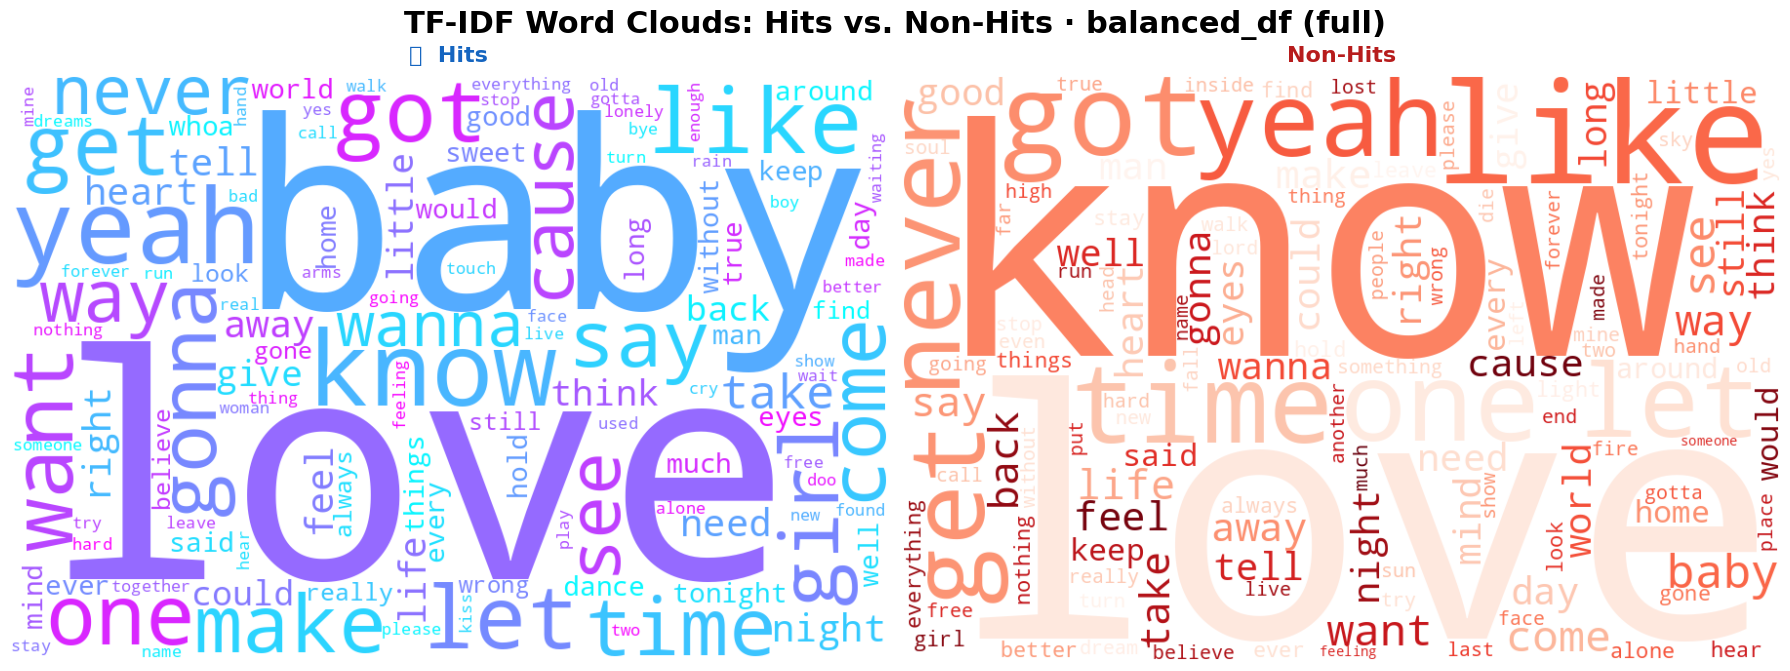

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from better_profanity import profanity
import matplotlib.pyplot as plt
import nltk
import re
import numpy as np

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

profanity.load_censor_words()

STOPWORDS = set(stopwords.words('english')) | {str(w) for w in profanity.CENSOR_WORDSET} | {
    "oh", "ah", "na", "la", "da", "ooh", "hey", "ha",
    "t", "s", "m", "re", "ll", "ve", "d",
}

def clean_lyrics(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(words)

# ── Rejoin decade ──────────────────────────────────────────────────────────
decade_lookup = songs_df[["id", "decade"]].drop_duplicates("id")
df_wc = balanced_df.merge(decade_lookup, on="id", how="left")

print("Cleaning lyrics...")
df_wc["lyrics_clean"] = df_wc["lyrics"].apply(clean_lyrics)
df_wc = df_wc.dropna(subset=["lyrics_clean"])
df_wc = df_wc[df_wc["lyrics_clean"].str.strip() != ""]

# ── TF-IDF across all individual songs ────────────────────────────────────
print("Computing TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df_wc["lyrics_clean"])
vocab = vectorizer.get_feature_names_out()

# ── Average TF-IDF score per word for hits vs non-hits ────────────────────
print("Averaging scores...")
hit_mask    = (df_wc["is_hit"] == 1).values
nonhit_mask = (df_wc["is_hit"] == 0).values

hit_scores    = tfidf_matrix[hit_mask].mean(axis=0).A1
nonhit_scores = tfidf_matrix[nonhit_mask].mean(axis=0).A1

hit_word_scores    = {vocab[i]: hit_scores[i]    for i in hit_scores.argsort()[::-1][:200]    if hit_scores[i] > 0}
nonhit_word_scores = {vocab[i]: nonhit_scores[i] for i in nonhit_scores.argsort()[::-1][:200] if nonhit_scores[i] > 0}

# ── Plot ───────────────────────────────────────────────────────────────────
print("Generating word clouds...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor="white")
fig.suptitle("TF-IDF Word Clouds: Hits vs. Non-Hits · balanced_df (full)",
             fontsize=22, fontweight="bold", color="black")

for ax, (word_scores, colormap, label, color) in zip(axes, [
    (hit_word_scores,    "cool", "🎵  Hits",  "#1565c0"),
    (nonhit_word_scores, "Reds", "Non-Hits", "#b71c1c"),
]):
    wc = WordCloud(
        width=900, height=600,
        background_color="white",
        colormap=colormap,
        max_words=120,
        prefer_horizontal=0.85,
        min_font_size=9,
    ).generate_from_frequencies(word_scores)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(label, fontsize=16, fontweight="bold", color=color, pad=10)

plt.tight_layout()
plt.savefig("wordclouds_tfidf_hit_vs_nonhit.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()